

## Objetivo
Analizar las tendencias en el contenido de Netflix mediante el análisis exploratorio de datos.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

## Carga del Dataset
Cargamos nuestro archivo en un dataframe con pandas, dicho archivo puede ser en multiples formatos pero para este proceso utilice un .csv disponible en "Kaggle", el link es el siguiente: https://www.kaggle.com/datasets/shivamb/netflix-shows 

In [12]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Info

Revisando nuestro dataframe podemos obtener información respecto a cada elemento, con el metodo .info obtenemos un resumen del df completo, en este caso podemos observar que cuenta con 8807 filas, 12 columnas y algo importante que podemos ver es que tanto las columnas de "director", "cast", "country", "date_added", "rating" y "duration"

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Limpieza de datos
Como detectamos contenido faltante en la tabla esto podria causar algun tipo de problematica a la hora de realizar el analisis, por lo tanto eliminaremos aquellas tablas donde exista un dato faltante, en este caso solo tomaremos "type", "country" y "release_year" ya que son aquellas donde el contenido es necesario para realizar los analisis

In [14]:
df = df.dropna(subset=["type", "country", "release_year"]) 
df.isnull().sum() # Observamos cuantos valores nulos quedaron 

show_id            0
type               0
title              0
director        2225
cast             671
country            0
date_added         9
release_year       0
rating             3
duration           3
listed_in          0
description        0
dtype: int64

## 1. Analisis del tipo de contenido

Para realizar un analisis de el tipo de contenido consumido en Netflix, tendremos que realizar un conteo para cada tipo de dato en "type", en este caso solo existe tanto MOVIE como TV SHOW, por lo que se suma cada contenido con ese tipo.

type
Movie      5691
TV Show    2285
Name: count, dtype: int64


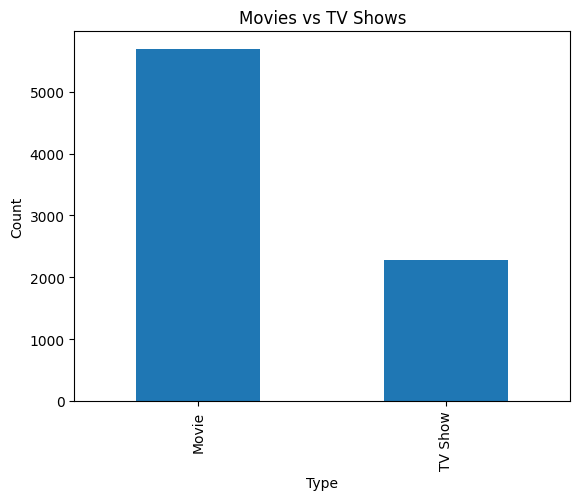

In [15]:
type_counts = df["type"].value_counts()
print(type_counts)
type_counts.plot(kind="bar") 
plt.title("Movies vs TV Shows") 
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Como podemos ver en la grafica, la mayoria del contenido disponible en Netflix corresponde a Peliculas, siento dos veces superior a las series. 

## 2. Top Generos

Otro dato que queremos saber es que generos son los mas producidos, como existe una gran cantidad de generos diferentes solo tomaremos en cuenta los 10 generos que mas predominen en Netflix, una buena de ver la representación es mediante una grafica de barras ya que nos permiten comparar las magnitudes entre cada tipo de genero.

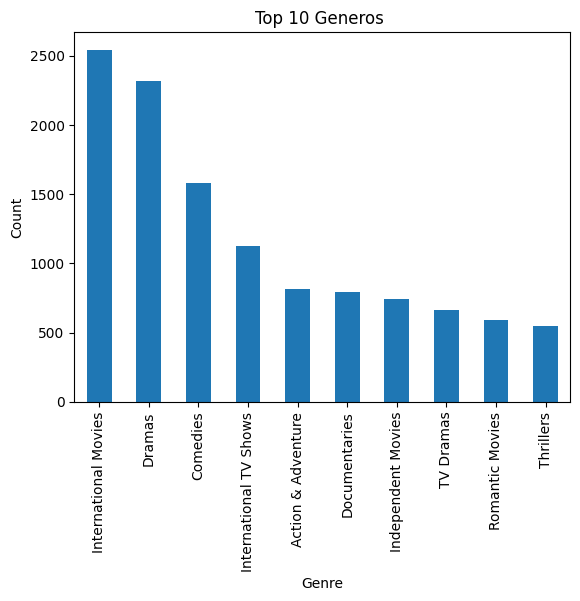

In [16]:
genres = df["listed_in"].str.split(", ").explode() #Dado que una serie o pelicula puede tener mas de un genero tendremos que separarlo para tomarlo en cuenta
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Generos ")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

En el resultado de nuestra grafica, encontramos que "International Movies" es el TOP 1, si bien no es un genero como tal si nos dice que existe una gran parte del contenido que no esta unicamente en Ingles, seguido de eso nos encontramos con Drama, y comedias, siendo de los contenidos mas producidos, estos datos son relevantes ya que nos ayudan a saber cual es la tendencia general de produccióm, se podria hacer un top de generos por años para saber que tan producido es un genero a lo largo de los años.

## 3. Top Paises

Otro dato interesante que vendria bien saber es el Top de paises que producen mayor cantidad de contenido, nuevamente una grafica de barras es la mejor forma de representar estos datos.

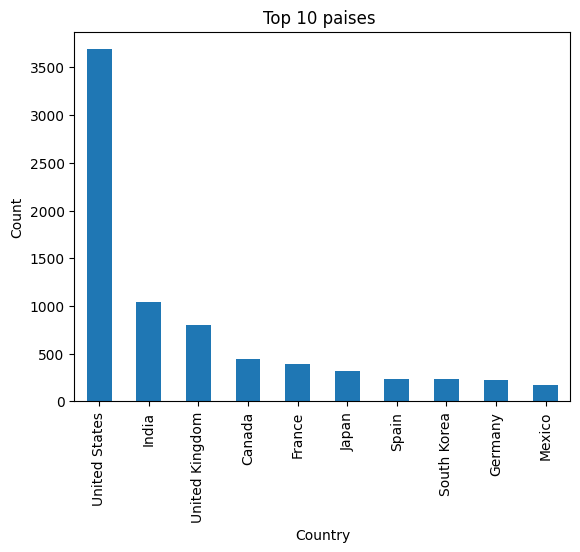

In [17]:
countries = df["country"].str.split(", ").explode()
countries.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 paises ")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

Nuestra grafica nos muestra que Estados Unidos es el mayor productor de peliculas y series que tiene Netflix, India toma el segundo lugar ya que es el mayor productor de peliculas en el mundo, pero como solo tomamos en cuenta aquello que esta adentro de la plataforma de Netflix no puede superar a Estados Unidos.

## 4. Crecimiento del contenido a lo largo del tiempo


Nuestro ultimo dato a observar es el crecimiento de contenido por año, a diferencia de las graficas anteriores en esta ocasión es mejor utilizar una grafica de linea ya que visualmente podemos ver el comportamiento por año de contenido producido.

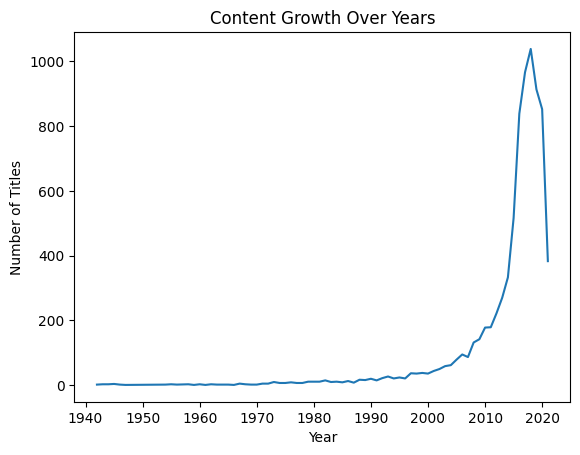

In [18]:
df["release_year"].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Lo impactante en esta grafica es como el contenido a inicios del 2020 fue en picada a pesar de el crecimiento gigante de los años pasados, esta caida podemos justificarla debido a la pandemia del COVID-19 ya que paro muchas producciones de todo el mundo, dando como resultado poco contenido producido.

## Conclusiones destacables

Como resultado general pude observar lo siguiente:

- Las peliculas son mas comunes que los TV shows.
- Estados unidos es el mayor productor de contenido en Netflix
- El contenido crecio significativamente despues del 2015 pero tuvo una picada debido a la pendemia del COVID-19
- El drama y la comedia son los generos mas predominantes dentro del catalogo de Netflix.